In [1]:
from collections import Counter, defaultdict
from matplotlib.lines import Line2D
from scipy.spatial import distance
import matplotlib.pyplot as plt
from rdkit import Chem
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import os
import tarfile
import pymol
from pymol import cmd
import matplotlib.image as mpimg
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
from rdkit.Chem.QED import qed
import matplotlib.patches as patches
from pycirclize import Circos
from itertools import combinations
from matplotlib.colors import to_hex
import numpy as np
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

In [3]:
DOCKING_RESULTS_REAL_2 = {}

# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/notebooks'
PATH_TO_DOCKING_RESULTS_REAL_2 = os.path.join(root, "..", "processed", "unidock_REAL_docking_2", 'docking_results')

# Mapping IDs to SMILES
ID_TO_SMILES = pd.read_csv(os.path.join(root, "..", "processed", "unidock_REAL_docking", 'inference_10B', 'clustered_compounds.csv'))
ID_TO_SMILES = {i: j for i,j in zip(ID_TO_SMILES['id'], ID_TO_SMILES['smiles'])}

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))
pocket_detection_data_interpro = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data_interpro.tsv"), sep='\t')

# Uniprot to gene name
uniprot_to_gene = pd.read_csv(os.path.join(root, "..", "data", "mtb_trna_synthetases_bosch_2021_fig5.csv"))
uniprot_to_gene = {i: j for i,j in zip(uniprot_to_gene['uniprot_ac'], uniprot_to_gene['gene_name_in_bosch_2021'])}

# Load pocket coordinates
pocket_to_coords = {}
for file, pocket_numb, coord in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'], pocket_detection_data['Pocket centroid coordinate (x y z)']):
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

# For each pocket - REAL 2
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL_2))):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL_2, pocket, 'report.csv'))
    assert len(scores) == 99105
    DOCKING_RESULTS_REAL_2[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# Define pockets, compounds and proteins
POCKETS = sorted(DOCKING_RESULTS_REAL_2)
COMPOUNDS = sorted(DOCKING_RESULTS_REAL_2[POCKETS[0]])
PROTEINS = sorted(set([i.split("_")[1] for i in POCKETS]))
print(f"Number of pockets: {len(POCKETS)}")
print(f"Number of compounds: {len(COMPOUNDS)}")
print(f"Number of proteins: {len(PROTEINS)}")

100%|██████████| 276/276 [00:11<00:00, 24.40it/s]

Number of pockets: 276
Number of compounds: 99105
Number of proteins: 21


In [6]:
# Get minimum docking scores per protein
DOCKING_RESULTS_ORIGINAL_PROTEINS = {i: defaultdict(int) for i in PROTEINS}
for pocket in tqdm(POCKETS):
    protein = pocket.split("_")[1]
    for cpd in sorted(DOCKING_RESULTS_REAL_2[pocket]):
        DOCKING_RESULTS_ORIGINAL_PROTEINS[protein][cpd] = min(DOCKING_RESULTS_ORIGINAL_PROTEINS[protein][cpd], DOCKING_RESULTS_REAL_2[pocket][cpd])

100%|██████████| 276/276 [00:05<00:00, 54.84it/s]


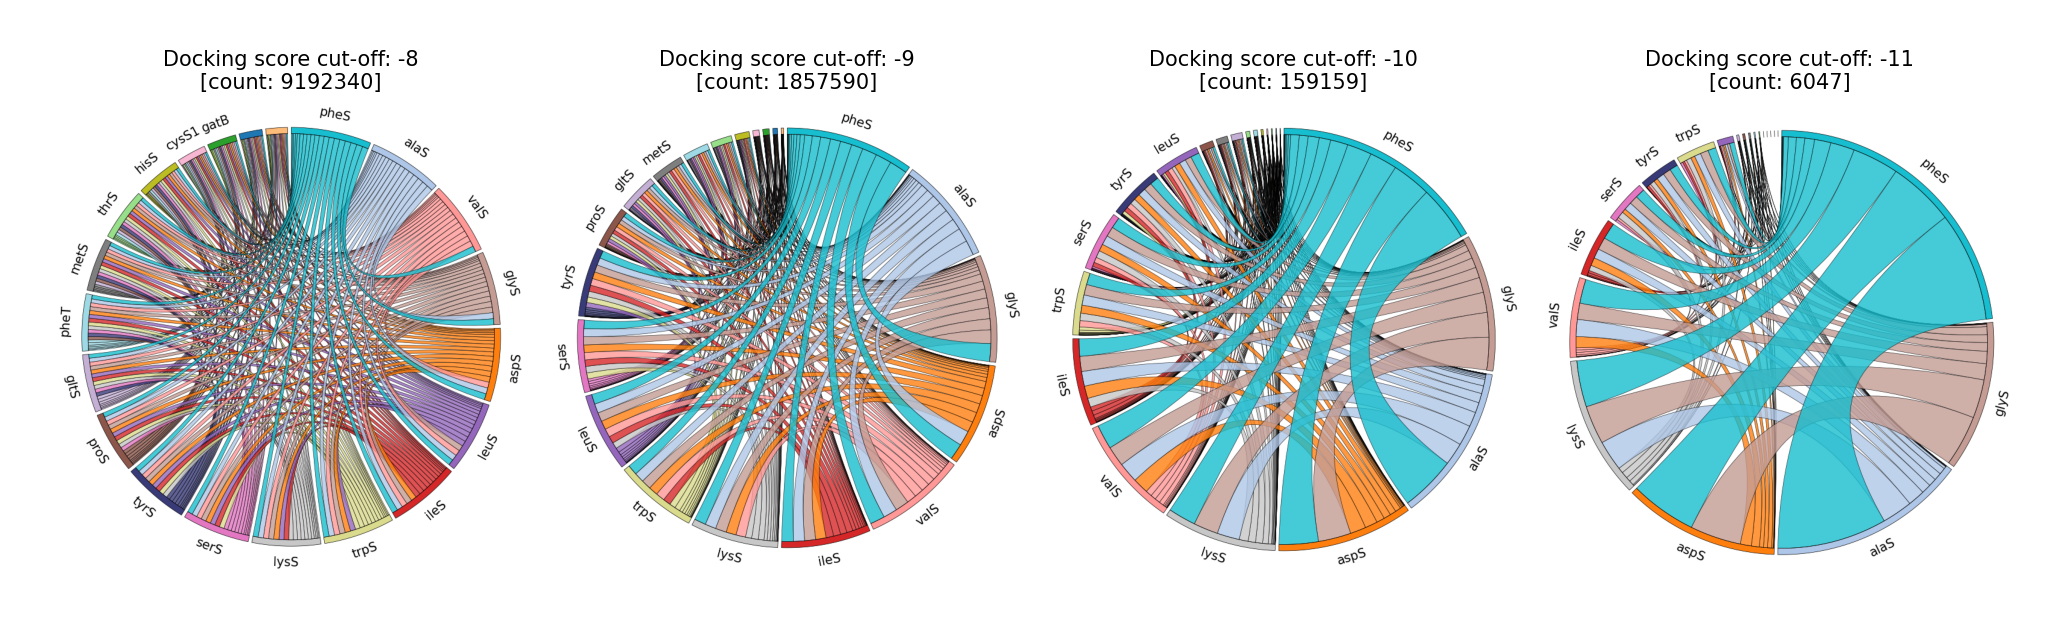

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(20, 6))

# cmap_dict = {'argS':'#50285A','alaS':'#FAD782','aspS':'#FAA08B','gatA':'#DC9FDC','gatB':'#AA96FA','thrS':'#8DC7FA','ileS':'#BEE6B4',
#              'valS':'#D2D2D2','leuS':'#F26B38','gltS':'#4D9DE0','proS':'#6CC551','glyS':'#FFC857','serS':'#E76F51','cysS1':'#2A9D8F',
#              'metS':'#F4A259','lysS':'#8A5082','hisS':'#247BA0','trpS':'#70C1B3','pheS':'#F25F5C','pheT':'#FFE066','tyrS':'#1B9C85'}

uniprot_ids = ["P9WFW5","P9WFW7","P9WFW3","P9WQA1","P9WN61","P9WFT5","P9WFV3","P9WFS9","P9WFV1","P9WFV9","P9WFT9","P9WFV7","P9WFT7",
            "P9WFW1","P9WFU5","P9WFU9","P9WFV5","P9WFT3","P9WFU3","P9WFU1","P9WFT1"]

palette = list(plt.get_cmap("tab20").colors) + [plt.get_cmap("tab20b").colors[0]]
cmap_dict = {uniprot_to_gene[uid]: to_hex(palette[i]) for i, uid in enumerate(uniprot_ids)}

def get_hit_overlap(h1, h2):
        return len(h1.intersection(h2))

for count, SCORE_CUTOFF in enumerate([-8, -9, -10, -11]):

    proteins = sorted(set([p.split("_")[1] for p in DOCKING_RESULTS_REAL_2]))
    proteins_to_hits = {p: set() for p in proteins} 

    for pocket in sorted(DOCKING_RESULTS_REAL_2):
        p = pocket.split("_")[1]
        hits = [cpd for cpd, score in DOCKING_RESULTS_REAL_2[pocket].items() if score < SCORE_CUTOFF]
        proteins_to_hits[p].update(hits)

    HIT_OVERLAP = {}
    for c1, p1 in enumerate(proteins):
        for p2 in proteins[c1:]:
            ov = get_hit_overlap(proteins_to_hits[p1], proteins_to_hits[p2])
            HIT_OVERLAP[(p1, p2)] = ov
            HIT_OVERLAP[(p2, p1)] = ov

    row_names = proteins
    matrix = [[HIT_OVERLAP[(i, j)] for j in row_names] for i in row_names]
    matrix_df = pd.DataFrame(matrix, index=row_names, columns=row_names)
    np.fill_diagonal(matrix_df.values, 0)
    node_strength = matrix_df.sum(axis=0) + matrix_df.sum(axis=1)
    order = node_strength.sort_values(ascending=False).index
    matrix_df = matrix_df.loc[order, order]
    matrix_df_genes = matrix_df.rename(index=uniprot_to_gene).rename(columns=uniprot_to_gene)

    node_strength = (matrix_df_genes.sum(axis=0) + matrix_df_genes.sum(axis=1)) / 2
    total_sum = matrix_df_genes.values.sum() / 2
    thr = total_sum / 25
    rename_map = {}
    c = 1
    for g in matrix_df_genes.index:
        if node_strength.loc[g] < thr:
            rename_map[g] = " " * c
            cmap_dict[" " * c] = cmap_dict[g]
            c += 1
    matrix_df_plot = matrix_df_genes.rename(index=rename_map).rename(columns=rename_map)
    matrix_df_plot.values[np.tril_indices_from(matrix_df_plot, k=1)] = 0

    circos = Circos.chord_diagram(
        matrix_df_plot,
        space=1,
        cmap=cmap_dict,
        label_kws=dict(size=15),
        link_kws=dict(ec="k", lw=0.5, alpha=0.8))

    plot = circos.plotfig()

    canvas = FigureCanvas(plot)
    canvas.draw()
    w, h = plot.canvas.get_width_height()
    img = np.frombuffer(canvas.tostring_argb(), dtype=np.uint8).reshape(h, w, 4)[:, :, [1,2,3,0]] 

    ax[count].set_title(f"Docking score cut-off: {SCORE_CUTOFF}\n[count: {int(total_sum)}]", size=15)
    ax[count].imshow(img)
    ax[count].axis("off")
    plt.close(plot)


plt.tight_layout()
plt.show()